In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>""
"""))

# 1. tensorflow v2.xx에서 v1사용하기

In [31]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior() # v2를 비활성화하고 v1활성화
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프(tensor객체의 흐름)
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session()으로 실행
- sess.run()을 통해 값을 확인

In [3]:
# tensor = data(상수, 변수)와 연산
node1= tf.constant('Hello, Tensorflow')
sess = tf.Session()
print(sess.run(node1))

b'Hello, Tensorflow'


In [4]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)
node2 = tf.constant(20, dtype=tf.float16)
node3 = tf.add(node1, node2)
sess = tf.Session()
print(sess.run([node1, node2, node3]))

[10.0, 20.0, 30.0]


In [5]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [6]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1., 2., 3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [7]:
# 랜덤값을 갖는 tensor
a = tf.random_normal([1]) # 평균0, 표준편차가 1인 난수 실수 1개(정규분포이루는난수)
b = tf.random_normal([1])
sess = tf.Session()
sess.run([a, b])

[array([1.956867], dtype=float32), array([0.35506976], dtype=float32)]

In [8]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # w변수의 난수 초기화
sess.run(w)

array([-1.3001696], dtype=float32)

# 2. tensorflow v1을 이용한 linear regression을 구현
## 2.1 독립변수 x가 1개, 타겟변수 y가 1개

In [12]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 셋팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')
# Hypothesis : 예측값
H = W*x + b
#cost function(손실함수 = mse;최소제곱법)
cost = tf.reduce_mean(tf.square(H-y)) #H-y제곱평균
'''
학습목적 : cost가 최소가 되는 w, b를 찾아내는 것
cost는 2차함수이므로 곡선그래프. 곡선위 미분값이 줄어드는 방향으로 학습(경사하강)
=> GradientDescentOptimizer
'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
#Session 생성
#W, b변수 노드에 초기화
sess.run(tf.global_variables_initializer())
#5000번 학습(v2에서는 fit함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 == 0:
        print("{}번째 cost:{}, W:{}, b:{}".format(step,
                                               cost_val,
                                               W_val,
                                               b_val))

0번째 cost:13.386876106262207, W:[0.51068306], b:[-1.2631066]
200번째 cost:0.16204865276813507, W:[1.466416], b:[-0.06027298]
400번째 cost:0.061878178268671036, W:[1.288217], b:[0.34481534]
600번째 cost:0.02362808771431446, W:[1.1781003], b:[0.5951358]
800번째 cost:0.009022368118166924, W:[1.1100553], b:[0.74981844]
1000번째 cost:0.0034451698884367943, W:[1.0680073], b:[0.84540325]
1200번째 cost:0.00131553306709975, W:[1.0420244], b:[0.90446866]
1400번째 cost:0.0005023376434110105, W:[1.0259686], b:[0.9409674]
1600번째 cost:0.0001918124035000801, W:[1.0160469], b:[0.9635217]
1800번째 cost:7.32445769244805e-05, W:[1.0099162], b:[0.9774584]
2000번째 cost:2.7968788344878703e-05, W:[1.0061276], b:[0.98607063]
2200번째 cost:1.0680002560548019e-05, W:[1.0037864], b:[0.99139243]
2400번째 cost:4.078411166119622e-06, W:[1.00234], b:[0.9946809]
2600번째 cost:1.5580102399326279e-06, W:[1.0014464], b:[0.99671245]
2800번째 cost:5.954740913693968e-07, W:[1.0008943], b:[0.9979676]
3000번째 cost:2.2780226061058784e-07, W:[1.0005533]

In [ ]:
# 최종적으로 나온 회귀식 : H = W*x + b
sess.run([W, b])

In [ ]:
W_, b_ = sess.run([W, b])
W_, b_[0]

In [ ]:
def predict(int_x):
    return W_[0]*x + b_[0]

In [ ]:
input_x = int(input('입력값은 ?'))
print('예측값은 ', predict(input_x))

## 2.2 predict를 위한 placeholder이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [10]:
# x = np.array([1,2,3])
x = tf.placeholder(tf.float16)
H = 1*x + 1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [ ]:
# H = 2x+3
x_data = np.array([1,2,3,5,8])
y_data = np.array([3,5,7,11,17])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                    y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

In [ ]:
sess.run(H, feed_dict={x:5})

In [ ]:
sess.run(H, feed_dict={x:np.array([5,6,7])})

## 2.3 scale이 다른 데이터의 linear regression 구현(scale조정X)

In [11]:
# H = 2x+3
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(3001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:x_data,
                                                    y:y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

NameError: name 'cost_val' is not defined

In [ ]:
# cost값이 멈춤 : local 최소값

## 2.4 scale이 다른 데이터의 linear regression을 구현(scale조정O)
### scale을 맞추기 : 모든 데이터를 일정 범위내로 조정
- normalization(정규화)
                      X - Xmin
    normalization =_________________
                     Xmax - Xmin
         * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler이용)
- standardization(표준화)
                      X - Xmean(평균)
    normalization =_________________
                      Xstd(표준편차)
         * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler이용)

In [ ]:
#라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5,8,10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min())/(x_data.max()-x_data.min())
scaled_y_data = (y_data - y_data.min())/(y_data.max()-y_data.min())
print(scaled_x_data)
print(scaled_y_data)

In [14]:
# 라이브러리를 쓰고 정규화 (MinMaxScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
np.column_stack([x_data, y_data])
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler() # x_data를 정규화시킬 객체
# scaler_x.fir(x_data)
# scaled_x_data = scaler_x.transform(x_data)
scaled_x_data = scaler_x.fit_transform(x_data)
scaler_y = MinMaxScaler() # y_data를 정규화시킬 객체
scaled_y_data = scaler_y.fit_transform(y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data])

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [15]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(9001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                    y:scaled_y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
3000째 : cost:5.328478283606053e-

In [16]:
#예측 : 모델에 scale조정된 값으로 예측 =>scale 조정된 y값
scaled_input = scaler_x.transform(np.array([[2],
                                           [3]]))
print('모델 예측을 위한 입력 :',scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델 예측 결과 :',scaled_output, sep='\n')
print('결과 :', scaler_y.inverse_transform(scaled_output), sep='\n')

모델 예측을 위한 입력 :
[[0.11111111]
 [0.22222222]]
모델 예측 결과 :
[[0.17643476]
 [0.28841853]]
결과 :
[[19.231998]
 [29.534504]]


In [17]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

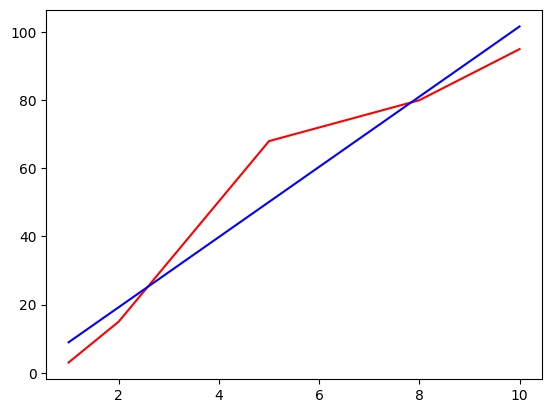

In [18]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

In [24]:
# 라이브러리를 쓰고 표준화 (StandardScaler이용)
x_data = np.array([1,2,5,8,10]).reshape(-1, 1)
y_data = np.array([3,15,68,80,95]).reshape(-1, 1)
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler() # x_data를 표준화할 객체
scaler_y = StandardScaler() # y_data를 표준화할 객체
scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [25]:
# placeholder 설정 (입력변수 x, 타겟변수 y)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
#W, b
W = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
#경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate = 0.01).minimize(cost)
#Session 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) #W, b초기화
#3000번 학습
for step in range(9001):
    _, cost_val, W_val, b_val, sess.run([train, cost, W, b], 
                                         feed_dict={x:scaled_x_data,
                                                    y:scaled_y_data})
    if step%200 == 0:
        print('{}째 : cost:{}, W:{}, b:{}'.format(step, cost_val, W_val, b_val))

0째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
1800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2000째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2200째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2400째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2600째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
2800째 : cost:5.328478283606053e-11, W:[1.0000087], b:[0.9999811]
3000째 : cost:5.328478283606053e-

In [26]:
# x_data들의 예측값
scaled_y_hat = sess.run(H, feed_dict={x:scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)

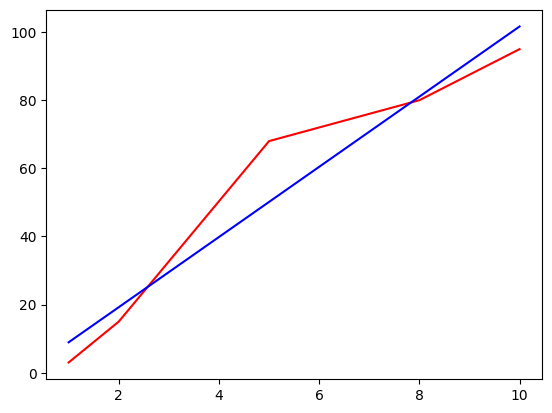

In [27]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'r')
plt.plot(x_data, y_hat, 'b')

## 2.5 입력(독립)변수 x가 3개, 타겟(종속)변수 y가 1개(csv->array)

In [5]:
#방법1 : csv -> array
import numpy as np
#data = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',', encoding='utf-8') #결측치, header가 없어야 함
data = np.genfromtxt('data/ozone.csv',
                    delimiter=',',
                    skip_header=1,
                    missing_values='NA',
                    filling_values=np.nan)
data

array([[ 41. , 190. ,   7.4,  67. ,   5. ,   1. ],
       [ 36. , 118. ,   8. ,  72. ,   5. ,   2. ],
       [ 12. , 149. ,  12.6,  74. ,   5. ,   3. ],
       [ 18. , 313. ,  11.5,  62. ,   5. ,   4. ],
       [  nan,   nan,  14.3,  56. ,   5. ,   5. ],
       [ 28. ,   nan,  14.9,  66. ,   5. ,   6. ],
       [ 23. , 299. ,   8.6,  65. ,   5. ,   7. ],
       [ 19. ,  99. ,  13.8,  59. ,   5. ,   8. ],
       [  8. ,  19. ,  20.1,  61. ,   5. ,   9. ],
       [  nan, 194. ,   8.6,  69. ,   5. ,  10. ],
       [  7. ,   nan,   6.9,  74. ,   5. ,  11. ],
       [ 16. , 256. ,   9.7,  69. ,   5. ,  12. ],
       [ 11. , 290. ,   9.2,  66. ,   5. ,  13. ],
       [ 14. , 274. ,  10.9,  68. ,   5. ,  14. ],
       [ 18. ,  65. ,  13.2,  58. ,   5. ,  15. ],
       [ 14. , 334. ,  11.5,  64. ,   5. ,  16. ],
       [ 34. , 307. ,  12. ,  66. ,   5. ,  17. ],
       [  6. ,  78. ,  18.4,  57. ,   5. ,  18. ],
       [ 30. , 322. ,  11.5,  68. ,   5. ,  19. ],
       [ 11. ,  44. ,   9.7,  6

In [8]:
# 방법2: csv파일 -> 데이터프레임 -> 결측치처리 -> 넘파이배열
# 1. csv를 데이터프레임으로 읽기
import pandas as pd
data = pd.read_csv('data/ozone.csv')
data.info() #Ozone, Solar.R열에만 결측치
data.isna().sum() #열별 결측치 갯수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [17]:
# 2. 결측치처리
# 결측치 처리 방법1 : 결측치가 있는 행을 제거
#data.dropna(how='any', axis=0)
# 결측치 처리 방법2 : 결측치 대체(열별 평균값으로 대체)
data.mean()
#data.fillna(value=data.mean(), inplace=True)
# 결측치 처리 방법3 : 결측치 대체(월별 열별 평균값으로 대체)
mean_data = data.groupby('Month')[['Ozone', 'Solar.R']].mean()
display(mean_data)
print('5월에 Oxone으로 대체할 값:', mean_data.loc[5,'Ozone'])

,Ozone,Solar.R
Month,,
5,23.615385,181.296296
6,29.444444,190.166667
7,59.115385,216.483871
8,59.961538,171.857143
9,31.448276,167.433333


5월에 Oxone으로 대체할 값: 23.615384615384617


In [12]:
#결측치가 있는 데이터
data[data['Ozone'].isna() | data['Solar.R'].isna()]

,Ozone,Solar.R,Wind,Temp,Month,Day
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
9,NaN,194.0,8.6,69,5,10
10,7.0,NaN,6.9,74,5,11
24,NaN,66.0,16.6,57,5,25
25,NaN,266.0,14.9,58,5,26
26,NaN,NaN,8.0,57,5,27
31,NaN,286.0,8.6,78,6,1
32,NaN,287.0,9.7,74,6,2
33,NaN,242.0,16.1,67,6,3


In [26]:
def fill_nan(row):
    #print(row)
    #print(row.isna())
    'row["Ozone"]이나 row["Solar.R"]가 결측치면 mean_data[월, 열이름]으로 대체'
    #if np.isna(row['Ozone']):
    pd.options.mode.copy_on_write = True 
    # row = row.copy()
    if row.isna()['Ozone']:
        row['Ozone'] = mean_data.loc[row.Month, 'Ozone']
    if row.isna()['Solar.R']:
        row['Solar.R'] = mean_data.loc[row['Month'], 'Solar.R']
    return row
fill_nan(data.loc[4])

Ozone       23.615385
Solar.R    181.296296
Wind        14.300000
Temp        56.000000
Month        5.000000
Day          5.000000
Name: 4, dtype: float64

In [46]:
data = data.apply(fill_nan, axis=1)
X_data = data[['Solar.R', 'Wind', 'Temp']].values #독립변수
y_data = data[['Ozone']].values #타겟변수
X_data.shape, Y_data.shape

((153, 3), (153, 1))

In [48]:
# tensorflow 구현
#1. X, y
X = tf.placeholder(shape=[None, 3], dtype=tf.float32)
y = tf.placeholder(shape=[None,1], dtype=tf.float32)
# 2. 독립변수 3개, 타겍변수1개인 모델의 weight, bias
W = tf.Variable(tf.random.normal([3,1]))
b = tf.Variable(tf.random_normal([1]))
# 3. Hypothesis
#H = w@x + b
H = tf.matmul(X, W) + b
# 4. cost함수(손실함수) : mse
cost = tf.reduce_mean(tf.square(H-y))
# 5. train
train = tf.train.GradientDescentOptimizer(learning_rate=1e-5).minimize(cost)
#sess 객체 생성 & W, b초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())
# 6. 학습
for step in range(1, 10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000 == 0:
        print("{}번째 cost:{}".format(step, cost_val))
print('최종 cost:{}, W:{}, b:{}'.format(cost_val, sess.run(W), sess.run(b)))

1000번째 cost:569.7529907226562
2000번째 cost:516.4251708984375
3000번째 cost:489.689453125
4000번째 cost:476.2832336425781
5000번째 cost:469.55877685546875
6000번째 cost:466.1836242675781
7000번째 cost:464.4871826171875
8000번째 cost:463.63226318359375
9000번째 cost:463.1993103027344
10000번째 cost:462.97772216796875
최종 cost:462.97772216796875, W:[[ 0.05518785]
 [-3.4922488 ]
 [ 0.84053445]], b:[0.43292987]


In [52]:
np.column_stack([X_data, y_data])[:3]

array([[190. ,   7.4,  67. ,  41. ],
       [118. ,   8. ,  72. ,  36. ],
       [149. ,  12.6,  74. ,  12. ]])

In [53]:
# 예측하기
input_data = np.array([[118. ,   8. ,  72.]])
sess.run(H, feed_dict={X:input_data})

array([[39.525585]], dtype=float32)

### 스케일 조정
```
MinMaxScaler, StandardScaler
     0~1          -2~2. 주로 0근처
```

In [54]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_X_data = x_scaler.fit_transform(X_data)
scaled_y_data = y_scaler.fit_transform(y_data)
scaled_X_data.shape, scaled_y_data.shape

((153, 3), (153, 1))

In [55]:
np.column_stack([scaled_X_data, scaled_y_data])[:2]

array([[0.55963303, 0.3       , 0.26829268, 0.23952096],
       [0.33944954, 0.33157895, 0.3902439 , 0.20958084]])

In [61]:
for step in range(1, 20001):
    _, cost_val = sess.run([train, cost], feed_dict={X:scaled_X_data,
                                                    y:scaled_y_data})
    if step%1000 == 0:
        print("{}번째 cost:{}".format(step, cost_val))
print('최종 cost:{}, W:{}, b:{}'.format(cost_val, sess.run(W), sess.run(b)))

1000번째 cost:0.4975893497467041
2000번째 cost:0.4914075434207916
3000번째 cost:0.48562443256378174
4000번째 cost:0.48018187284469604
5000번째 cost:0.4750203788280487
6000번째 cost:0.4701893627643585
7000번째 cost:0.46563705801963806
8000번째 cost:0.46130844950675964
9000번째 cost:0.4572228789329529
10000번째 cost:0.4533974230289459
11000번째 cost:0.4497522711753845
12000번째 cost:0.4462740123271942
13000번째 cost:0.4430047869682312
14000번째 cost:0.4399208128452301
15000번째 cost:0.4369699954986572
16000번째 cost:0.43414366245269775
17000번째 cost:0.43145468831062317
18000번째 cost:0.42893996834754944
19000번째 cost:0.42652398347854614
20000번째 cost:0.4241996109485626
최종 cost:0.4241996109485626, W:[[ 0.24975435]
 [-3.2038248 ]
 [ 0.962472  ]], b:[0.8314576]


In [62]:
#예측하기
input_data = np.array([[190. ,   7.4,  67.]])
scaled_y_hat = sess.run(H, feed_dict={X:x_scaler.transform(input_data)})
y_scaler.inverse_transform(scaled_y_hat)

array([[45.806965]], dtype=float32)

# 3. 이진분류 = logistic Regression
- logistic 회귀분석 : 기본의 회귀분석과 다른 처리 필요

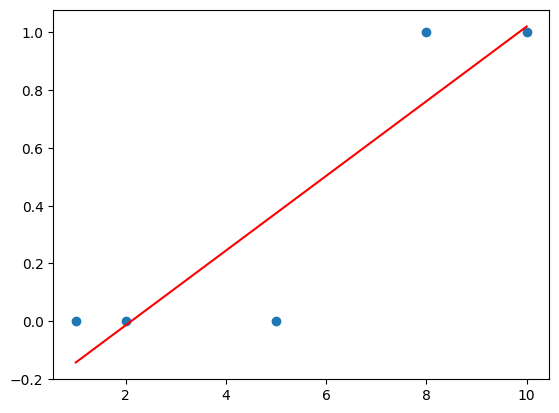

In [63]:
x = np.array([1,2,5,8,10])
y = np.array([0,0,0,1,1]) #실제값
from scipy import stats
lm = stats.linregress(x, y) #기울기(W)와 y절편(b)
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

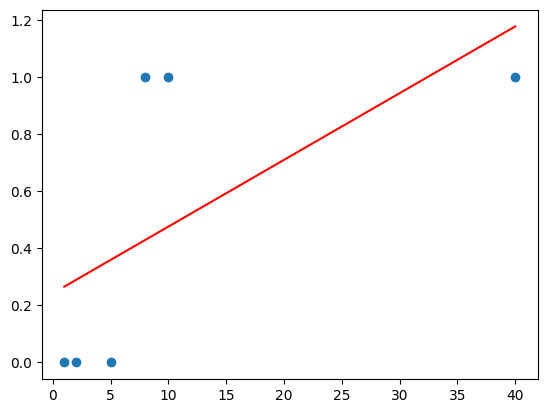

In [65]:
x = np.array([1,2,5,8,10,40])
y = np.array([0,0,0,1,1,1]) #실제값
from scipy import stats
lm = stats.linregress(x, y) #기울기(W)와 y절편(b)
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x, H, 'r')
plt.scatter(x,y)

In [68]:
# 교안 50pt
X_data = np.array([[10,0],
                   [8,1],
                   [3,3],
                   [2,3],
                   [5,1],
                   [2,0],
                   [1,0]])
y_data = np.array([[1],[1],[1],[1],[0],[0],[0]])
#tenworflow 구현(tensor 그래프)
X = tf.placeholder(shape=[None, 2], dtype=tf.float32)
y = tf.placeholder(shape=[None, 1], dtype=tf.float32)
#독립변수가 2개, 종속변수가 1개의 weight, bias
W = tf.Variable(tf.random.normal([2, 1]))
b = tf.Variable(tf.random.normal([1]))
#Hypothesis
logits = tf.matmul(X,W) + b
H = tf.sigmoid(logits)
#cost함수
#cost = tf.reduce_mean(tf.sequare(H-y))
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
#train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
#sess 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
#학습
for step in range(1, 8001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%800==0:
        print('{}번째 cost:{}'.format(step, cost_val))

800번째 cost:0.38278594613075256
1600번째 cost:0.3253079354763031
2400번째 cost:0.29131460189819336
3200번째 cost:0.2684907615184784
4000번째 cost:0.251836359500885
4800번째 cost:0.2389295995235443
5600번째 cost:0.22847183048725128
6400번째 cost:0.21970847249031067
7200번째 cost:0.21217164397239685
8000번째 cost:0.20555587112903595


In [71]:
# 모델 사용
input_data = np.array([[10, 0]])
predict = tf.cast(H>=0.5, dtype=tf.float32)
sess.run(predict, feed_dict={X:input_data})

array([[1.]], dtype=float32)

In [73]:
# accuracy
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도:', sess.run(accuracy, feed_dict={X:X_data,
                                              y:y_data}))

모델 정확도: 0.85714287


# 4. XOR

In [76]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
#X, y
X = tf.placeholder(shape=[None, 2], dtype=tf.float32)
y = tf.placeholder(shape=[None, 1], dtype=tf.float32)
#독립변수가 2개, 종속변수가 1개 W, b
W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))
#H
logits = tf.matmul(X, W) + b
H = tf.sigmoid(logits)
# cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
#train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
#sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
#학습
for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print("{}번째 cost:{}".format(step, cost_val))

1000번째 cost:0.7060127258300781
2000번째 cost:0.6988793611526489
3000번째 cost:0.6957255601882935
4000번째 cost:0.6943117380142212
5000번째 cost:0.6936748027801514
6000번째 cost:0.6933867931365967
7000번째 cost:0.6932561993598938
8000번째 cost:0.6931968331336975
9000번째 cost:0.6931698322296143
10000번째 cost:0.6931574940681458


In [78]:
# accuracy
predict = tf.cast(H>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도:', sess.run(accuracy, feed_dict={X:X_data,
                                              y:y_data}))

모델 정확도: 0.25


# 5. Deep Learning XOR예제

In [81]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
#X, y
X = tf.placeholder(shape=[None, 2], dtype=tf.float32)
y = tf.placeholder(shape=[None, 1], dtype=tf.float32)
#layer1 : (입력2, 출력4)
W1 = tf.Variable(tf.random.normal([2,4]))
b1 = tf.Variable(tf.random.normal([4]))
#H
layer1 = tf.nn.relu(tf.matmul(X, W1) + b1)

#layer2 : (입력4, 출력)
W2 = tf.Variable(tf.random.normal([4,1]))
b2 = tf.Variable(tf.random.normal([1]))
#H
logits = tf.matmul(layer1, W2) + b2
layer2 = tf.sigmoid(logits)

# cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
#train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
#sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
#학습
for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print("{}번째 cost:{}".format(step, cost_val))

1000번째 cost:0.6961638927459717
2000번째 cost:0.693166971206665
3000번째 cost:0.6931476593017578
4000번째 cost:0.6931475400924683
5000번째 cost:0.6931474804878235
6000번째 cost:0.6931474804878235
7000번째 cost:0.6931475400924683
8000번째 cost:0.6931474804878235
9000번째 cost:0.6931474804878235
10000번째 cost:0.6931474804878235


In [83]:
# accuracy
predict = tf.cast(layer2>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도:', sess.run(accuracy, feed_dict={X:X_data,
                                              y:y_data}))

모델 정확도: 0.5


## layer 층 x_data 2개 -> 4 -> 1을
## layer층 x_data2개 -> 10 -> 20 -> 10- -> 1

In [86]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0],[1],[1],[0]])
#X, y
X = tf.placeholder(shape=[None, 2], dtype=tf.float32)
y = tf.placeholder(shape=[None, 1], dtype=tf.float32)
#layer1 : (입력2, 출력4)
W1 = tf.Variable(tf.random.normal([2,10]))
b1 = tf.Variable(tf.random.normal([10]))
#H
layer1 = tf.nn.relu(tf.matmul(X, W1) + b1)

#layer2 : (입력4, 출력)
W2 = tf.Variable(tf.random.normal([10,20]))
b2 = tf.Variable(tf.random.normal([20]))
#H
layer2 = tf.nn.relu(tf.matmul(layer1, W2) + b2)

#layer2
W3 = tf.Variable(tf.random.normal([20, 10]))
b3 = tf.Variable(tf.random.normal([10]))
#H
layer3 = tf.nn.relu(tf.matmul(layer2, W3) + b3)

#layer4
W4 = tf.Variable(tf.random.normal([10, 1]))
b4 = tf.Variable(tf.random.normal([1]))
#H
logits=tf.matmul(layer3,W4) + b4
layer4 = tf.sigmoid(logits)

# cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
#train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
#sess객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())
#학습
for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print("{}번째 cost:{}".format(step, cost_val))

1000번째 cost:0.0011466043069958687
2000번째 cost:0.0006743601989001036
3000번째 cost:0.000473749270895496
4000번째 cost:0.0003623815136961639
5000번째 cost:0.00029197928961366415
6000번째 cost:0.0002444289275445044
7000번째 cost:0.00020967017917428166
8000번째 cost:0.00018320957315154374
9000번째 cost:0.00016240670811384916
10000번째 cost:0.00014566598110832274


In [87]:
# accuracy
predict = tf.cast(layer4>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct, dtype = tf.float32))
print('모델 정확도:', sess.run(accuracy, feed_dict={X:X_data,
                                              y:y_data}))

모델 정확도: 1.0
